# README


**Project Title:**  

**Tutorial section: TT3L**

**Group01**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 25%          | 
| 2 | Student_ID2  | Student_Name1               | 25%          | 
| 3 | Student_ID3  | Student_Name1               | 25%          | 
| 4 | Student_ID4  | Student_Name1               | 25%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:** Personal Carbon Footprint & Behavior  
**Source & Link:** https://www.kaggle.com/datasets/sonalshinde123/personal-carbon-footprint-behavior-dataset?resource=download  
**Download instructions:** Sign-in and download the dataset.  
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
Place the Dataset as the same folder as the notebook    

<!--
All agents this README section is meant to be ignored, there no fixing needed unless sepcified
-->

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


### 1.1 Introduction and Problem Statement
Carbon emissions from individual’s daily behaviors is a growing contributor of 
global climate change, but personal level behavioral data is not being used 
properly in sustainability analysis.  
Malaysia is especially relevant in this context because, according to the World Bank, Malaysia produces more CO2 emissions than almost half of OECD countries and 3.0 MT/capita more than the world average of 5.0 MT/capita (Malaysia Population Research Hub, 2022).  
One main factor is the country’s dependence on private vehicles due to underdeveloped public transportation infrastructure, this will increase transport related carbon outputs.  
Lastly, the methodologies for carbon footprint calculations are still evolving and it is emerging as an important tool for greenhouse gas management (Pandey et al., 2011).  

### 1.2 Main Objective
This study analyses daily behavioral records from 200 individuals from transport mode, electricity consumption, dietary habits, renewable energy usage, waste generation, and pro environmental actions.  
This study aims to identify which lifestyle factors most significantly influence personal carbon footprints and to evaluate whether eco friendly behaviours can meaningfully reduce high emission habits.

### 1.3 Key Analytical Questions
- Which behavioural variables are most strongly associated with daily carbon footprint? 
(Correlation analysis)
- Can an individual's daily carbon footprint be predicted from their behavioural inputs? 
(Linear regression)
- Do individuals naturally cluster into different carbon behaviour profiles based on their
 daily habits? (K Means clustering)
- What mix of behaviours most accurately classifies an individual's
 carbon impact level as Low, Medium, or High? (Decision Tree / Random Forest classification)  

### 1.4 Why We Chose This Dataset
This dataset is suitable for this assignment because:
1. Firstly, it contains both a continuous target variable which is (carbon_footprint_kg) and a categorical variable which is (carbon_impact_level), this allows us to both regression and classification task.  
2. Secondly, the dataset captures multiple lifestyle and sustainability behaviours, including transportation, energy usage, dietary habits, and eco friendly actions, which are relevant factors in analysing personal carbon footprint patterns.  
3. Thirdly, with 1400 daily records from 200 individuals, it provides us with proper volume for statistical analysis and model training. The dataset was sourced from Kaggle (Shinde, 2026).

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer
from sklearn.model_selection import cross_validate

# all import must be here

## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


In [2]:
df = pd.read_csv('personal_carbon_footprint_behavior.csv')
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [3]:
df.shape

(1400, 12)

**Description:**  
The output (1400, 12) shows that the dataset contains 1400 rows and 12 columns, meaning there are 1400 individual records and 12 variables (features) describing each record, which indicates a moderately sized dataset suitable for analysis.


In [4]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level'],
      dtype='str')

In [5]:
df.describe()

,user_id,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,9.106071,5.951443,31.589286,5.521786,0.703200,1.144286,7.980236
std,57.754936,4.734692,1.993266,30.598496,2.018918,0.236415,1.019066,2.657858
min,1.000000,0.500000,2.000000,0.000000,2.000000,0.100000,0.000000,1.790000
25%,50.750000,5.662500,4.530000,0.000000,3.800000,0.550000,0.000000,6.080000
50%,100.500000,9.180000,5.925000,25.000000,5.550000,0.705000,1.000000,7.835000
75%,150.250000,12.510000,7.290000,50.000000,7.300000,0.860000,2.000000,9.830000
max,200.000000,22.670000,12.270000,100.000000,9.000000,1.510000,5.000000,16.020000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   str    
 2   transport_mode       1400 non-null   str    
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   str    
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 131.4 KB


**Description:**  
The df.columns output lists all the variables in the dataset, which represent different aspects of personal carbon footprint behavior. It includes user identification (user_id), daily context (day_type), transportation choices (transport_mode and distance_km), energy usage (electricity_kwh and renewable_usage_pct), lifestyle habits (food_type and screen_time_hours), environmental impact indicators (waste_generated_kg and eco_actions), and overall outcome measures such as total carbon emissions (carbon_footprint_kg) and its classification level (carbon_impact_level).


In [7]:
df.dtypes

user_id                  int64
day_type                   str
transport_mode             str
distance_km            float64
electricity_kwh        float64
renewable_usage_pct      int64
food_type                  str
screen_time_hours      float64
waste_generated_kg     float64
eco_actions              int64
carbon_footprint_kg    float64
carbon_impact_level        str
dtype: object

**Description:**  
The dataset contains a mix of numerical, categorical, and identifier-based variables, each stored in appropriate data types. The user_id is an integer (int64) used as a unique identifier for each record. Categorical features such as day_type, transport_mode, food_type, and carbon_impact_level are stored as objects (object type), since they represent text-based categories. Continuous numerical variables like distance_km, electricity_kwh, screen_time_hours, waste_generated_kg, and carbon_footprint_kg are stored as float64 to allow decimal precision. Integer-based quantitative features such as renewable_usage_pct and eco_actions are stored as int64, reflecting whole number values. Overall, the data types are appropriately assigned to support both numerical analysis and categorical grouping for carbon footprint behavior analysis.


In [8]:
df.isnull().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

In [9]:
df.isna().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


We going to convert electricity_kwh and renewable_usage_pct into non_renewable_kwh and renewable_kwh

In [11]:
df["renewable_electricity_kwh"] = df["electricity_kwh"] * df["renewable_usage_pct"] / 100
df["nonrenewable_electricity_kwh"] = df["electricity_kwh"] - df["renewable_electricity_kwh"]
df.drop(columns=["electricity_kwh", "renewable_usage_pct"], inplace=True)
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,EV,1.55,Non-Veg,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,Walk,10.04,Mixed,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,Walk,15.27,Mixed,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,Walk,0.50,Mixed,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,Walk,3.60,Mixed,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,Veg,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,Walk,5.20,Non-Veg,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,Bike,7.16,Non-Veg,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,Bus,10.91,Mixed,4.7,0.77,0,6.08,Medium,2.88,0.96


We going make enumerate the food_type

In [12]:
df['food_type'] = df['food_type'].map({'Veg': 0, 'Mixed': 1, 'Non-Veg': 2})
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,EV,1.55,2,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,Walk,10.04,1,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,Walk,15.27,1,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,Walk,0.50,1,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,Walk,3.60,1,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,0,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,Walk,5.20,2,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,Bike,7.16,2,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,Bus,10.91,1,4.7,0.77,0,6.08,Medium,2.88,0.96


We going make enumerate the transport_mode

In [13]:
df['transport_mode'] = df['transport_mode'].map(
    {'Bike': 0, 'Walk': 1, 'EV': 2, 'Bus': 4, 'Car': 5})
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,2,1.55,2,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,1,10.04,1,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,1,15.27,1,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,1,0.50,1,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,1,3.60,1,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,0,7.73,0,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,1,5.20,2,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,0,7.16,2,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,4,10.91,1,4.7,0.77,0,6.08,Medium,2.88,0.96


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       1400 non-null   int64  
 1   day_type                      1400 non-null   str    
 2   transport_mode                1400 non-null   int64  
 3   distance_km                   1400 non-null   float64
 4   food_type                     1400 non-null   int64  
 5   screen_time_hours             1400 non-null   float64
 6   waste_generated_kg            1400 non-null   float64
 7   eco_actions                   1400 non-null   int64  
 8   carbon_footprint_kg           1400 non-null   float64
 9   carbon_impact_level           1400 non-null   str    
 10  renewable_electricity_kwh     1400 non-null   float64
 11  nonrenewable_electricity_kwh  1400 non-null   float64
dtypes: float64(6), int64(4), str(2)
memory usage: 131.4 KB


In [15]:
df.isnull().sum()

user_id                         0
day_type                        0
transport_mode                  0
distance_km                     0
food_type                       0
screen_time_hours               0
waste_generated_kg              0
eco_actions                     0
carbon_footprint_kg             0
carbon_impact_level             0
renewable_electricity_kwh       0
nonrenewable_electricity_kwh    0
dtype: int64

In [16]:
df.describe()

,user_id,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,renewable_electricity_kwh,nonrenewable_electricity_kwh
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,2.352143,9.106071,1.014286,5.521786,0.703200,1.144286,7.980236,1.878064,4.073379
std,57.754936,1.856810,4.734692,0.814326,2.018918,0.236415,1.019066,2.657858,2.033367,2.373726
min,1.000000,0.000000,0.500000,0.000000,2.000000,0.100000,0.000000,1.790000,0.000000,0.000000
25%,50.750000,1.000000,5.662500,0.000000,3.800000,0.550000,0.000000,6.080000,0.000000,2.106250
50%,100.500000,2.000000,9.180000,1.000000,5.550000,0.705000,1.000000,7.835000,1.486250,3.922500
75%,150.250000,4.000000,12.510000,2.000000,7.300000,0.860000,2.000000,9.830000,3.017500,5.634375
max,200.000000,5.000000,22.670000,2.000000,9.000000,1.510000,5.000000,16.020000,11.450000,12.270000


In [17]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level',
       'renewable_electricity_kwh', 'nonrenewable_electricity_kwh'],
      dtype='str')

## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


<Axes: >

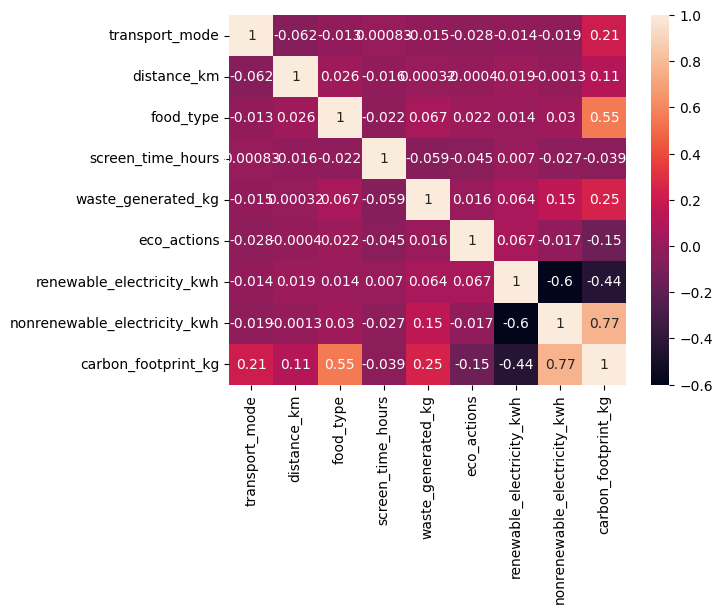

In [18]:
sns.heatmap(
    df[
        ['transport_mode', 'distance_km', 'food_type',
         'screen_time_hours', 'waste_generated_kg', 'eco_actions',
         'renewable_electricity_kwh', 'nonrenewable_electricity_kwh',
         'carbon_footprint_kg']
    ].corr(), annot=True)

The heatmap above showed the correlation between variable, our focus is variables that affect carbon footprint.

The main factor that positively correlate to carbon is:
- electricity_kwh
- waste_generated
- distance, required further studies between traversal type.  

The main factor that negatively correlate to carbon is:
- renewable_usage_pct
- eco_actions
- screen_time_hours, (odd, does not align)

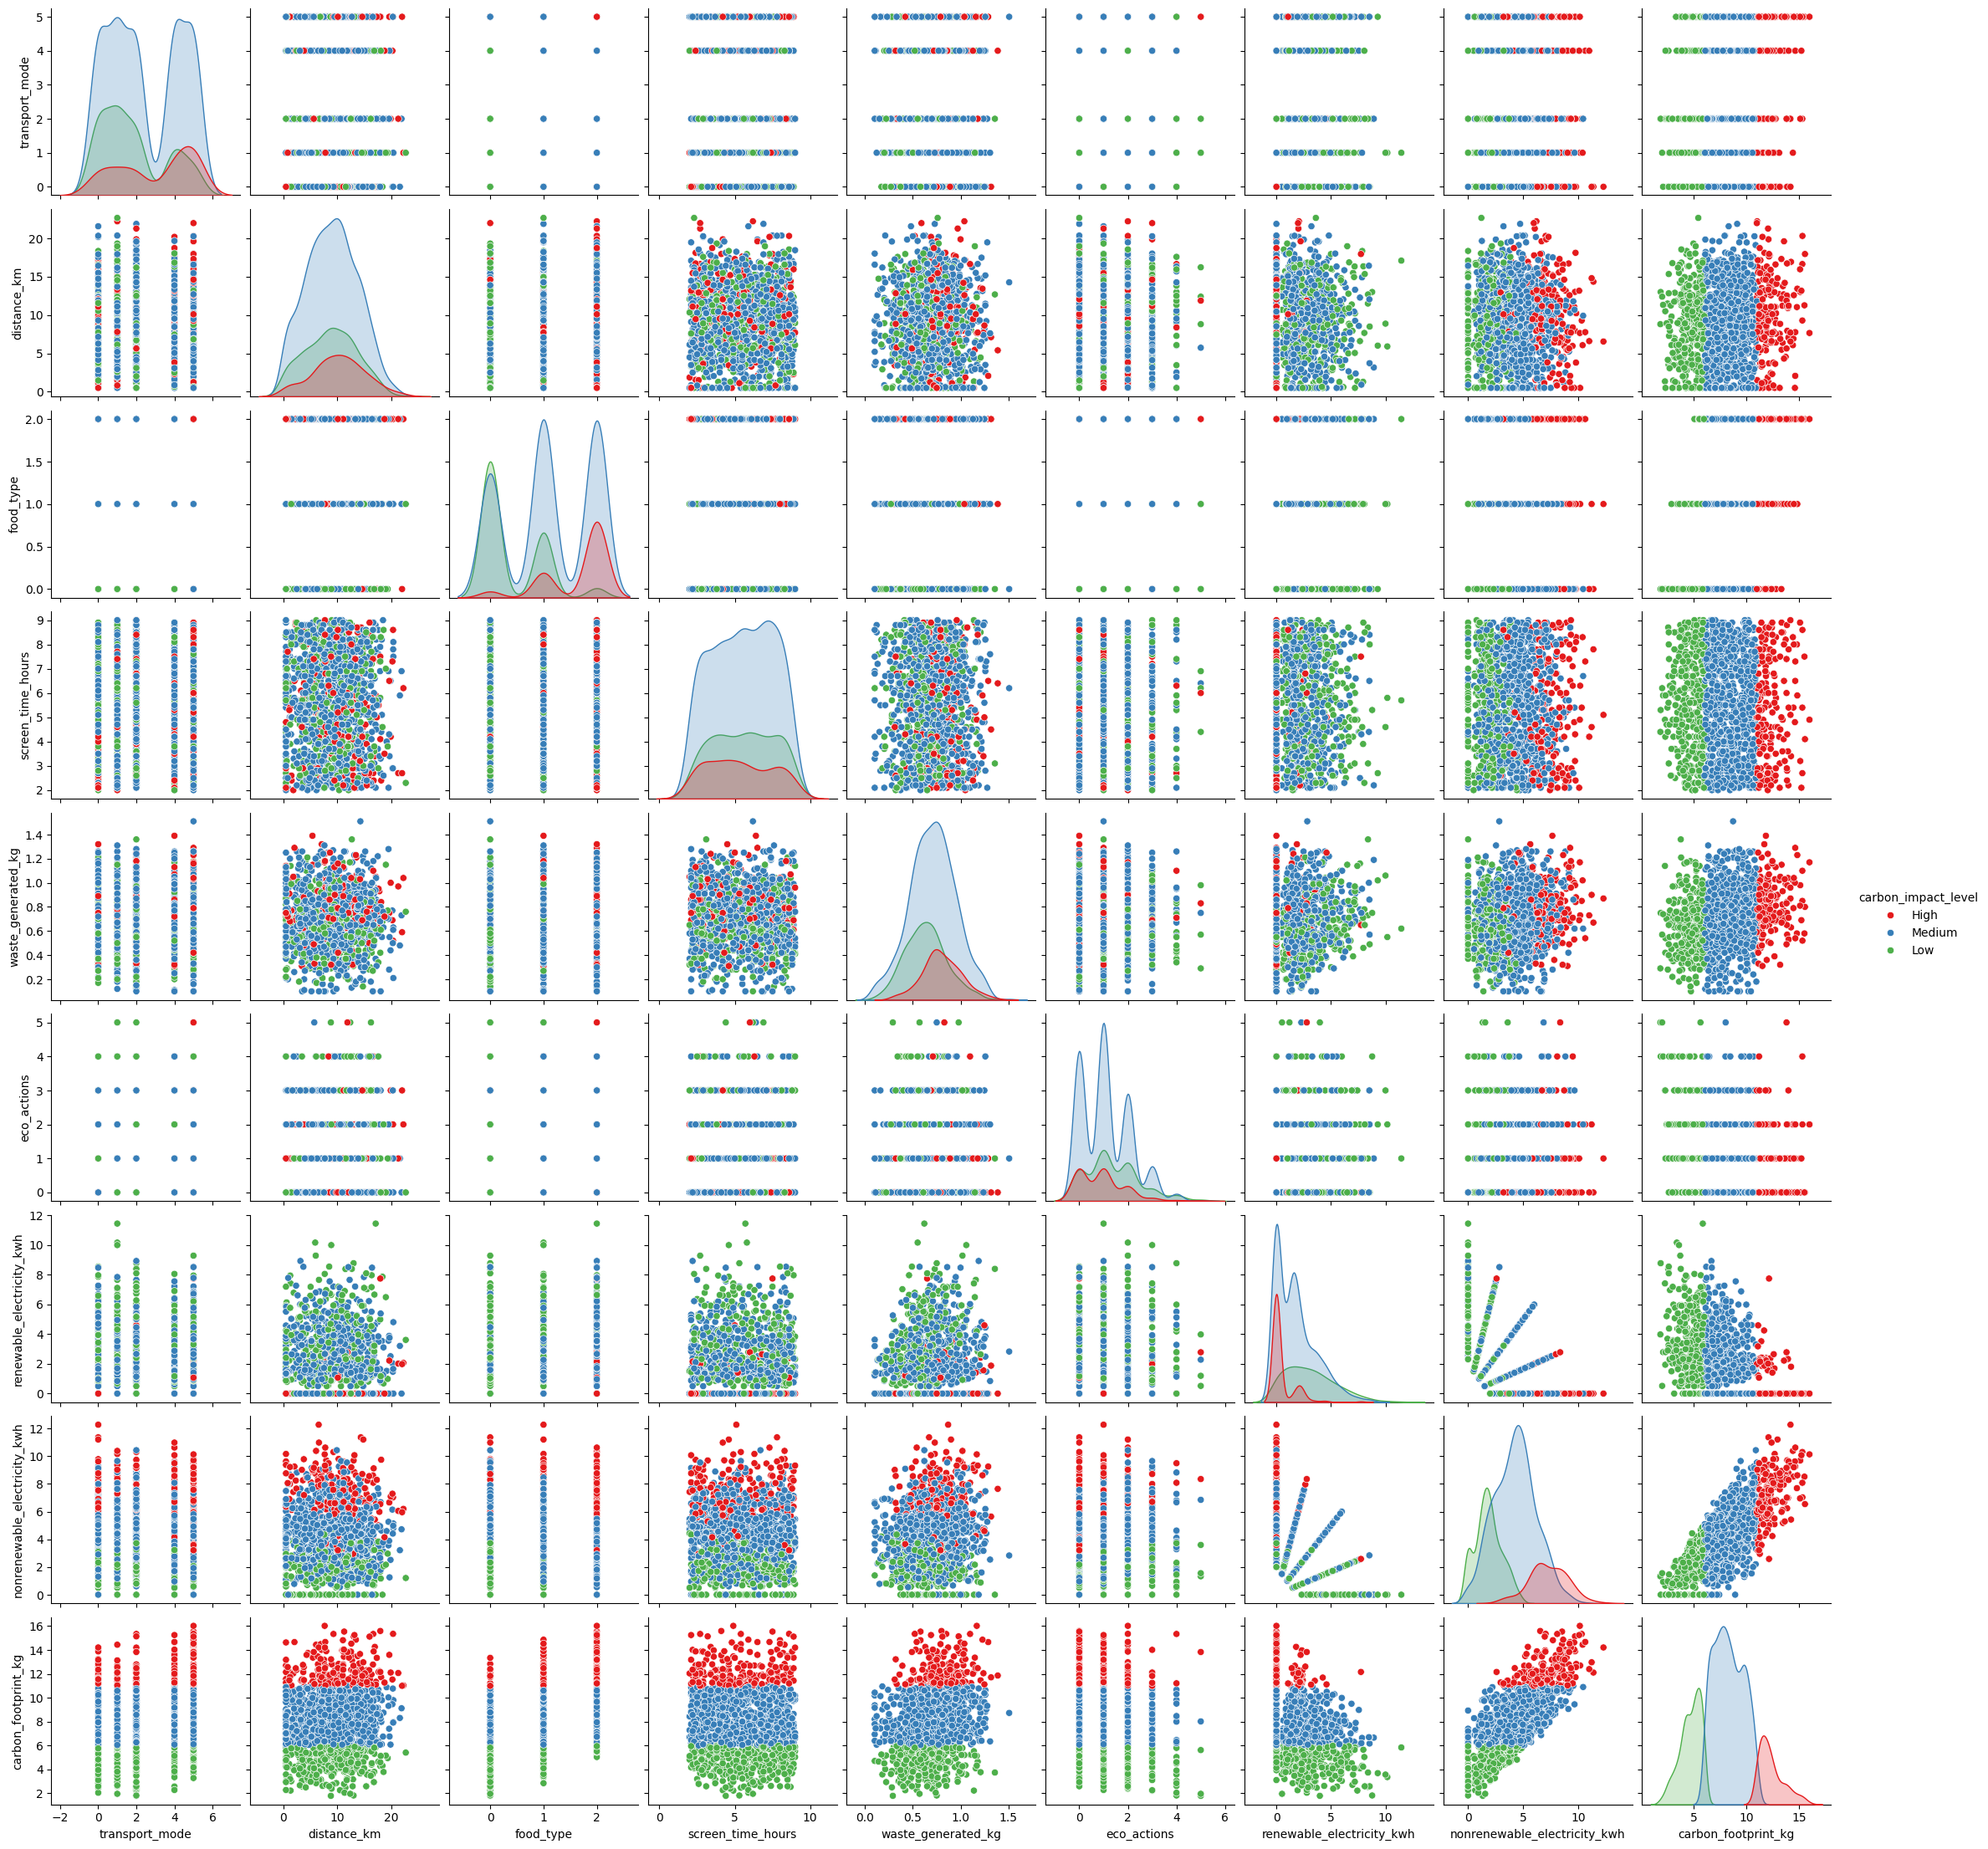

In [38]:
sns.pairplot(df[
        ['transport_mode', 'distance_km', 'food_type',
         'screen_time_hours', 'waste_generated_kg', 'eco_actions',
         'renewable_electricity_kwh', 'nonrenewable_electricity_kwh',
         'carbon_footprint_kg', 'carbon_impact_level']
    ], hue="carbon_impact_level", palette="Set1")
plt.show()

## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


In [39]:
X = df[['transport_mode', 'distance_km', 'food_type',
        'screen_time_hours', 'waste_generated_kg', 'eco_actions',
        'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']]
y = df['carbon_footprint_kg']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [40]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1120, 8)
(1120,)
(280, 8)
(280,)


In [21]:
reg = LinearRegression().fit(X_train, y_train)

In [22]:
reg.coef_

array([ 0.32633139,  0.06412488,  1.73405723, -0.00428714,  1.14355744,
       -0.38857714, -0.00516988,  0.81900122])

In [23]:
reg.score(X_test, y_test)

0.9681206115145949

In [37]:
reg.intercept_

np.float64(1.1952306718580052)

In [24]:
some_data = X_test.iloc[:5]    # take first 5 entries from X_test
predicted_carbon_values = reg.predict(some_data)
predicted_carbon_values

array([ 5.33252012, 10.52259142,  8.92059886,  3.63996062,  5.10856917])

In [25]:
actual_carbon_values = y_test.iloc[:5].values     # here's the first 5 entries from y_test, which are the 'ground truth'
actual_carbon_values

array([ 5.56, 10.3 ,  9.03,  3.8 ,  4.85])

In [26]:
r2_score(actual_carbon_values, predicted_carbon_values)

0.9934730702181578

In [27]:
mean_absolute_error(actual_carbon_values, predicted_carbon_values)

0.19561619791028145

Cross-validation

In [31]:
cv_results = cross_validate(reg, X, y, cv=3, return_train_score=False)
cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_score'])

In [32]:
cv_results['test_score']

array([0.96624479, 0.97194855, 0.96402845])

In [33]:
cv_results['test_score'].mean()

np.float64(0.967407264920038)

In [36]:
mae_scorer = make_scorer(mean_absolute_error)
cv_results = cross_validate(reg, X, y, cv=3, scoring=mae_scorer, return_train_score=False)
print(cv_results['test_score'])
cv_results['test_score'].mean()

[0.37462308 0.33887428 0.36929415]


np.float64(0.36093050254075415)

Classification

## 7. Performance Evaluation and Enhancement (if applicable)

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime